# Exploratory Data Analysis Notebook

This notebook contains multiple analyses for looking at quality of data and exploring patterns regarding the dataset versions: both the original, which had multiple health status values, along with metadata, and also the modified dataset, which includes binary health labels, and no metadata is used.

The same libraries are imported in separate cells, so to allow to test cells separately from each other.

In [ ]:
import pandas as pd

# Read original dataset (not binary health class)
bee_data = pd.read_csv("../data/raw/bee_data.csv")

# Top 5 lines
print(bee_data.head())

# Print shape, # of rows & # of columns 
print(bee_data.shape) 

          file     date   time        location  zip code subspecies  \
0  041_066.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
1  041_072.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
2  041_073.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
3  041_067.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
4  041_059.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   

              health  pollen_carrying   caste  
0  hive being robbed            False  worker  
1  hive being robbed            False  worker  
2  hive being robbed            False  worker  
3  hive being robbed            False  worker  
4  hive being robbed            False  worker  
(5172, 9)


In [ ]:
# Data Exploration

print("=" * 60)
print("ORIGINAL DATASET OVERVIEW")
print("=" * 60)

# Simple shape
print(f"\nDataset shape: {bee_data.shape}")
print(f"Total records: {bee_data.shape[0]}") # print dimension x
print(f"Total features: {bee_data.shape[1]}") # print dimension y

# Info about the columns, types, numbers
print("\n" + "=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)
print(bee_data.info())

# Describe statistics
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(bee_data.describe(include='all'))

# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

# See if there are missing values
missing = bee_data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

# Unique values
print("\n" + "=" * 60)
print("UNIQUE VALUES IN EACH COLUMN - Original DS")
print("=" * 60)

for col in bee_data.columns:
    unique_count = bee_data[col].nunique()
    print(f"{col}: {unique_count} unique values\n")

    if unique_count <= 10:
        print(f"  Values: {bee_data[col].unique()}")


ORIGINAL DATASET OVERVIEW

Dataset shape: (5172, 9)
Total records: 5172
Total features: 9

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   file             5172 non-null   object
 1   date             5172 non-null   object
 2   time             5172 non-null   object
 3   location         5172 non-null   object
 4   zip code         5172 non-null   int64 
 5   subspecies       5172 non-null   object
 6   health           5172 non-null   object
 7   pollen_carrying  5172 non-null   bool  
 8   caste            5172 non-null   object
dtypes: bool(1), int64(1), object(7)
memory usage: 328.4+ KB
None

STATISTICAL SUMMARY
               file     date   time           location      zip code  \
count          5172     5172   5172               5172   5172.000000   
unique         5172       16     35                  8    

In [ ]:
# Data Cleaning + Preparation

print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Check for duplicate rows
duplicates = bee_data.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    bee_data = bee_data.drop_duplicates()
    print(f"Dropped duplicates. New shape: {bee_data.shape}")

# 2 steps for handling the subspecies column (-1 indicates unknown)
print(f"\nSubspecies value counts:")
print(bee_data['subspecies'].value_counts())

# Step 1 Subspecies: Check which rows have subspecies equal to -1
unknown_mask = bee_data['subspecies'] == -1

# Step 2 Subspecies: Count how many TRUE values there are
subspecies_missing = unknown_mask.sum()

print(f"Missing subspecies (coded as -1): {subspecies_missing}")

# Examine other categorical columns
print("\nCaste value counts:")
print(bee_data['caste'].value_counts())

print("\nHealth value counts:")
print(bee_data['health'].value_counts())

print("\nPollen carrying value counts:")
print(bee_data['pollen_carrying'].value_counts())

# Check zip code distribution
print(f"\nZip code distribution: {bee_data['zip code'].nunique()} unique values")
print(bee_data['zip code'].value_counts().head(10))

# Handle potential data quality issues
print("\n" + "=" * 60)
print("DATA TYPE CONVERSIONS")
print("=" * 60)

# .csv has FALSE and TRUE, but these are not proper boolean types
# Ensure boolean column is in proper type
bee_data['pollen_carrying'] = bee_data['pollen_carrying'].astype(str).str.lower() == 'true'
print("Converted pollen_carrying to boolean type")

print(f"\nFinal dataset shape: {bee_data.shape}")
print(bee_data.head())

DATA CLEANING

Duplicate rows: 0

Subspecies value counts:
subspecies
Italian honey bee        3008
Russian honey bee         527
Carniolan honey bee       501
1 Mixed local stock 2     472
-1                        428
VSH Italian honey bee     199
Western honey bee          37
Name: count, dtype: int64
Missing subspecies (coded as -1): 0

Caste value counts:
caste
worker    5172
Name: count, dtype: int64

Health value counts:
health
healthy                       3384
few varrao, hive beetles       579
Varroa, Small Hive Beetles     472
ant problems                   457
hive being robbed              251
missing queen                   29
Name: count, dtype: int64

Pollen carrying value counts:
pollen_carrying
False    5154
True       18
Name: count, dtype: int64

Zip code distribution: 7 unique values
zip code
95070    2000
30607    1051
50315     973
77511     737
70115     170
95124     149
3431       92
Name: count, dtype: int64

DATA TYPE CONVERSIONS
Converted pollen_carrying to

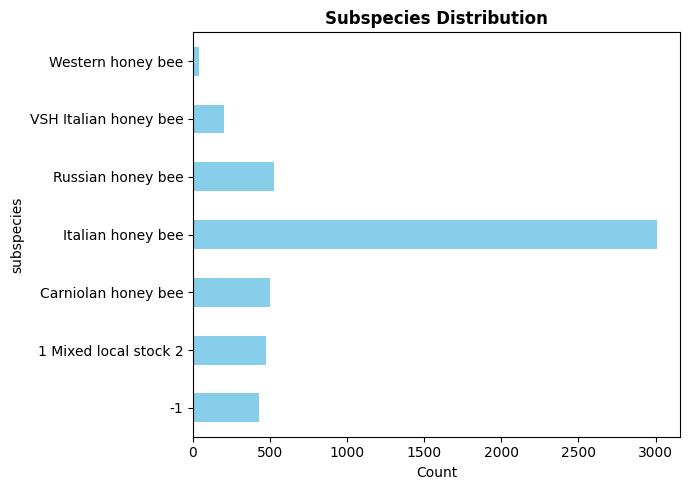

In [16]:
import matplotlib.pyplot as plt

# Exploratory visualization, useful graphs

# Plot 1: Subspecies distribution
plt.figure(figsize=(7, 5))
bee_data['subspecies'].value_counts().sort_index().plot(kind='barh', color='skyblue')
plt.title('Subspecies Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

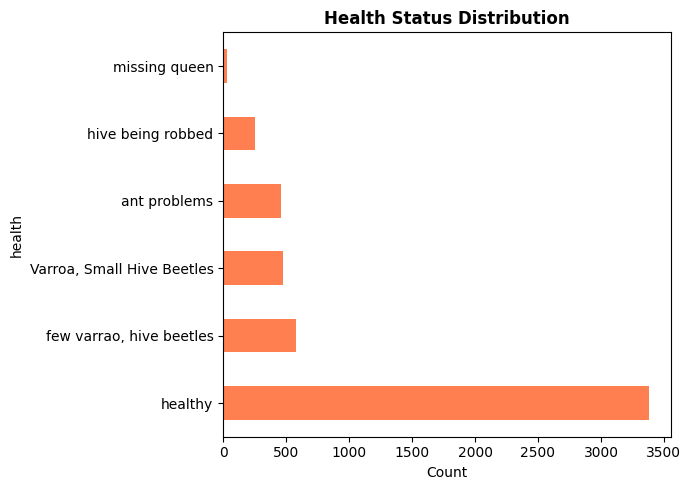

In [17]:
# Plot 2: Health distribution
plt.figure(figsize=(7, 5))
bee_data['health'].value_counts().plot(kind='barh', color='coral')
plt.title('Health Status Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

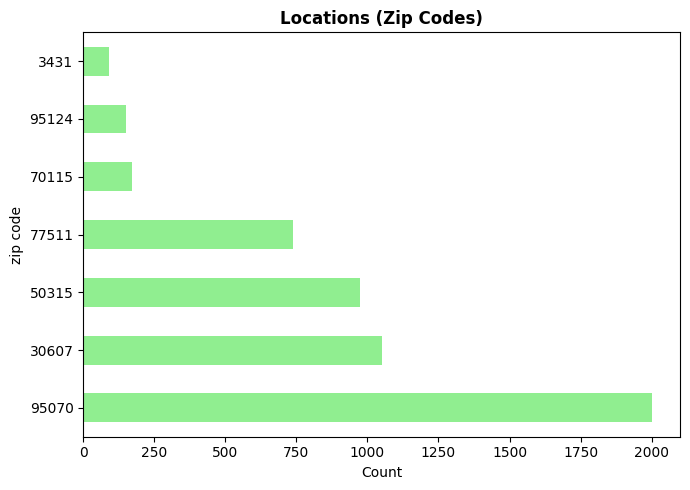

In [18]:
# Plot 3: Location Distribution
plt.figure(figsize=(7, 5))
bee_data['zip code'].value_counts().head(10).plot(kind='barh', color='lightgreen')
plt.title('Locations (Zip Codes)', fontsize=12, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

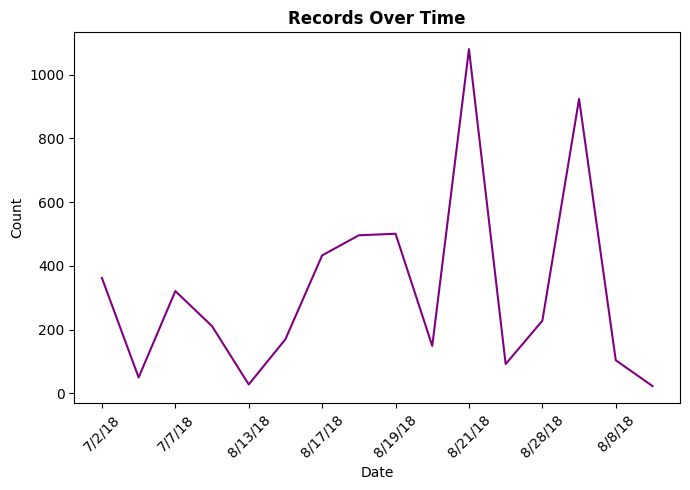

In [ ]:
# Plot 4: Records over time
plt.figure(figsize=(7, 5))
bee_data['date'].value_counts().sort_index().plot(kind='line', color='purple')
plt.title('Records Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\palag\AppData\Local\Temp\ipykernel_2596\403560595.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  corr_df["date_num"] = pd.to_datetime(corr_df["date"], errors="coerce").map(


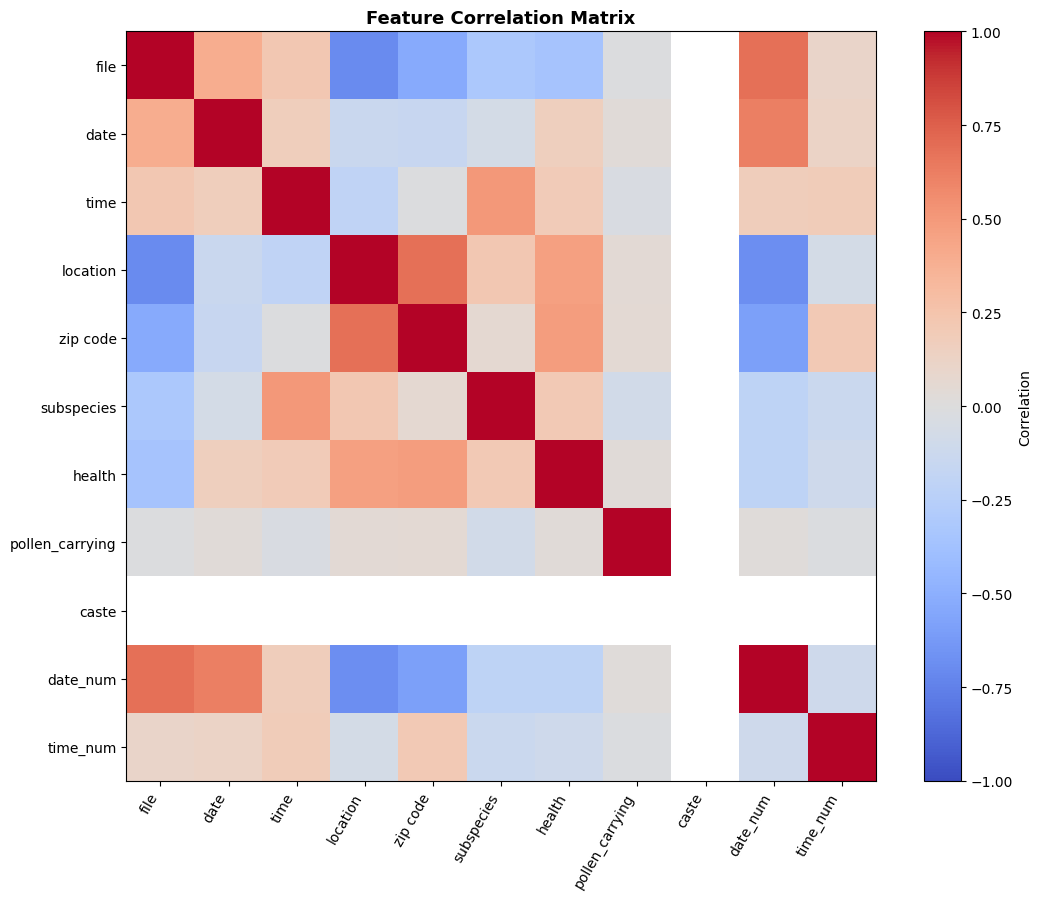

In [22]:
import numpy as np

corr_df = bee_data.copy()

# Convert date to numeric (ordinal day)
corr_df["date_num"] = pd.to_datetime(corr_df["date"], errors="coerce").map(
    lambda x: x.toordinal() if pd.notna(x) else np.nan
)

# Convert time to minutes from midnight
t = pd.to_datetime(corr_df["time"], format="%H:%M", errors="coerce")
corr_df["time_num"] = t.dt.hour * 60 + t.dt.minute

# Ensure boolean is numeric
if corr_df["pollen_carrying"].dtype == bool:
    corr_df["pollen_carrying"] = corr_df["pollen_carrying"].astype(int)

# Encode categorical/object columns for correlation matrix
for col in corr_df.select_dtypes(include=["object"]).columns:
    corr_df[col], _ = pd.factorize(corr_df[col], sort=True)

# Keep only numeric columns and compute correlation
numeric_corr = corr_df.select_dtypes(include=[np.number]).corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(11, 9))
cax = ax.imshow(numeric_corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_corr.columns)))
ax.set_yticks(range(len(numeric_corr.columns)))
ax.set_xticklabels(numeric_corr.columns, rotation=60, ha="right")
ax.set_yticklabels(numeric_corr.columns)

ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
fig.colorbar(cax, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

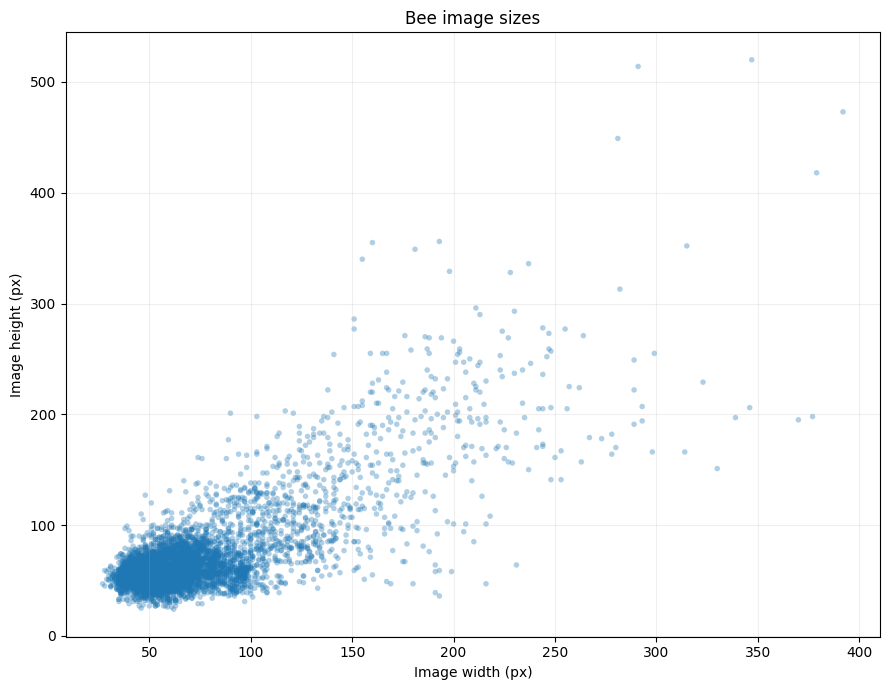

Plotted 5,172 images
Unique sizes: 3,057
Width range: 27-392 px | Height range: 24-520 px


In [1]:
from pathlib import Path
import struct

import pandas as pd
import matplotlib.pyplot as plt

# Load the metadata file and define the directory that contains the bee images
bee_sizes = pd.read_csv("../data/raw/bee_data.csv")
image_dir = Path("../data/bee_imgs")


# Read image width and height directly from the PNG header
# This is faster than loading every full image just to check its size
def read_png_size(image_path: Path) -> tuple[int, int]:
    with image_path.open("rb") as image_file:
        signature = image_file.read(8)
        if signature != b"\x89PNG\r\n\x1a\n":
            raise ValueError(f"Unsupported image format: {image_path.name}")

        image_file.read(4)
        chunk_type = image_file.read(4)
        if chunk_type != b"IHDR":
            raise ValueError(f"Missing IHDR chunk: {image_path.name}")

        width, height = struct.unpack(">II", image_file.read(8))
        return width, height


# Build full image paths and keep only files that are available in the dataset folder
bee_sizes["image_path"] = bee_sizes["file"].map(lambda file_name: image_dir / file_name)
bee_sizes = bee_sizes[bee_sizes["image_path"].map(Path.exists)].copy()

# Extract width and height for each existing image
bee_sizes[["image_width", "image_height"]] = bee_sizes["image_path"].apply(
    lambda image_path: pd.Series(read_png_size(image_path))
)

# Scatter plot of image width and height to see size variation in the dataset
plt.figure(figsize=(9, 7))
plt.scatter(
    bee_sizes["image_width"],
    bee_sizes["image_height"],
    s=16,
    alpha=0.35,
    color="#1f77b4",
    edgecolors="none",
)
plt.title("Bee image sizes")
plt.xlabel("Image width (px)")
plt.ylabel("Image height (px)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Print a short summary
print(f"Plotted {len(bee_sizes):,} images")
print(
    f"Unique sizes: {bee_sizes[['image_width', 'image_height']].drop_duplicates().shape[0]:,}"
)
print(
    f"Width range: {bee_sizes['image_width'].min()}-{bee_sizes['image_width'].max()} px | "
    f"Height range: {bee_sizes['image_height'].min()}-{bee_sizes['image_height'].max()} px"
)

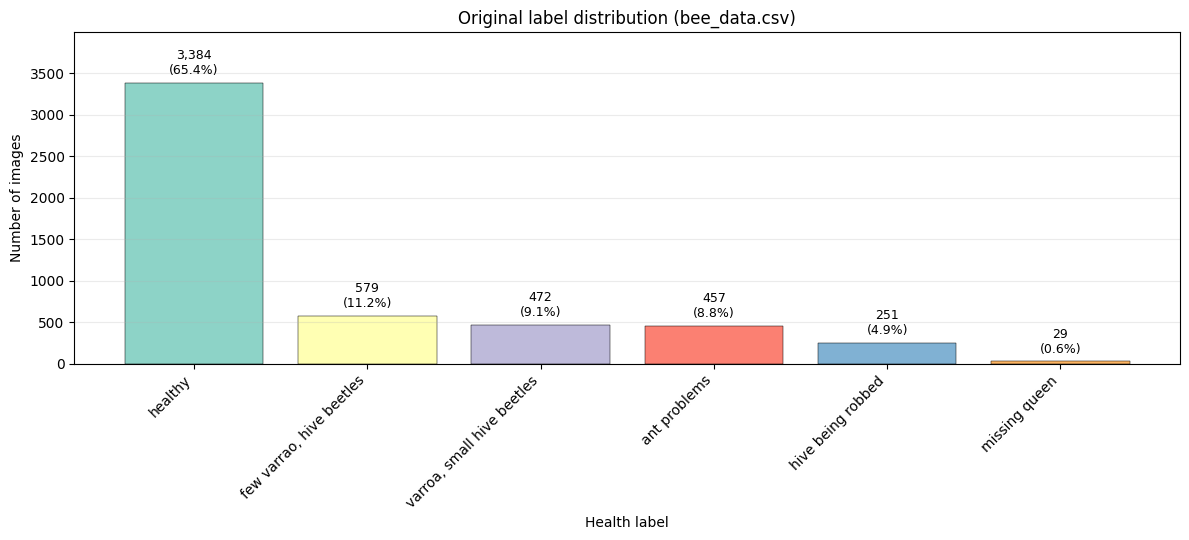

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the original dataset and count how many images belong to each health label
raw_df = pd.read_csv("../data/raw/bee_data.csv")
raw_health = raw_df["health"].astype(str).str.strip().str.lower()
raw_counts = raw_health.value_counts().sort_values(ascending=False)

# Prepare values for percentage labels above the bars
raw_total = raw_counts.sum()
max_count = raw_counts.max()
label_offset = max_count * 0.02

# Bar chart showing class distribution in the original multi-class dataset
plt.figure(figsize=(12, 5.5))
bar_colors = plt.cm.Set3(range(len(raw_counts)))
bars = plt.bar(raw_counts.index, raw_counts.values, color=bar_colors, edgecolor="black", linewidth=0.35)

# Add absolute counts and percentages above each bar
for bar, count in zip(bars, raw_counts.values):
    pct = (count / raw_total) * 100 if raw_total else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.title("Original label distribution (bee_data.csv)")
plt.ylabel("Number of images")
plt.xlabel("Health label")
plt.ylim(0, max_count * 1.18)
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

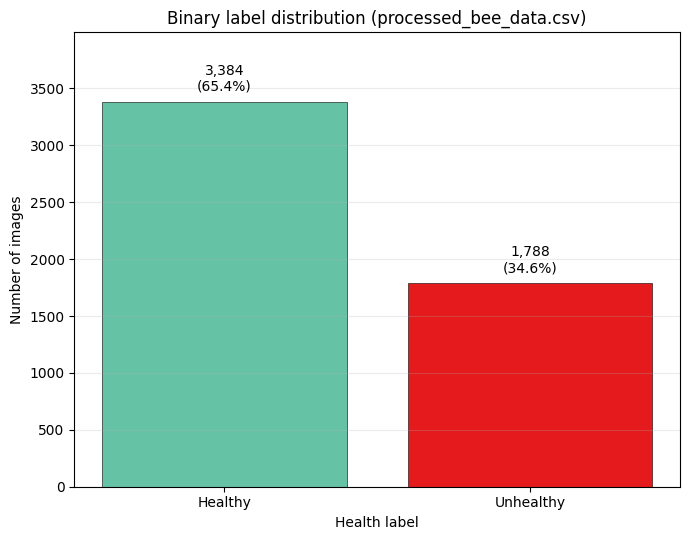

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load processed dataset and count how many images belong to each binary health label
processed_df = pd.read_csv("../data/processed/processed_bee_data_20260330_151740.csv", sep=";")

binary_counts = (
    processed_df["health"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
    .reindex(["healthy", "unhealthy"])
    .fillna(0)
    .astype(int)
)

# Prepare values for percentage labels above the bars
binary_total = binary_counts.sum()
max_count = binary_counts.max()
label_offset = max_count * 0.02

# Bar chart showing class distribution in the processed binary dataset
plt.figure(figsize=(7, 5.5))
binary_labels = [label.title() for label in binary_counts.index]
binary_colors = ["#66c2a5", "#e41a1c"]
bars = plt.bar(binary_labels, binary_counts.values, color=binary_colors, edgecolor="black", linewidth=0.4)

# Add absolute counts and percentages above each bar
for bar, count in zip(bars, binary_counts.values):
    pct = (count / binary_total) * 100 if binary_total else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.title("Binary label distribution (processed_bee_data.csv)")
plt.ylabel("Number of images")
plt.xlabel("Health label")
plt.ylim(0, max_count * 1.18)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

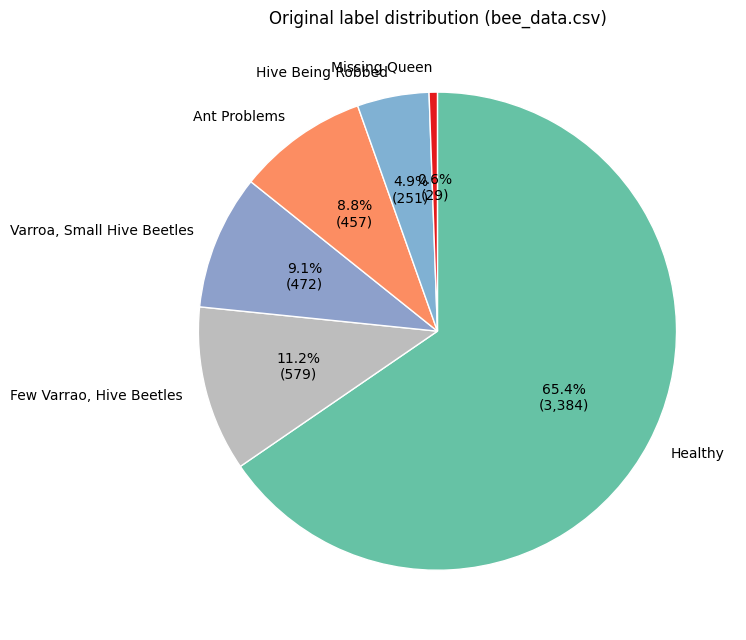

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load original dataset, count how many images belong to each health label
raw_df = pd.read_csv("../data/raw/bee_data.csv")
raw_health = raw_df["health"].astype(str).str.strip().str.lower()
raw_counts = raw_health.value_counts().sort_values(ascending=False)

# Convert label names to title case for cleaner plot labels
pie_labels = [label.title() for label in raw_counts.index]

# Use fixed color mapping so the same health classes keep the same colors in the chart
color_map = {
    "healthy": "#66c2a5",
    "few varroa, hive beetles": "#ffd92f",
    "varroa, small hive beetles": "#8da0cb",
    "ant problems": "#fc8d62",
    "hive being robbed": "#80b1d3",
    "missing queen": "#e41a1c",
}
pie_colors = [color_map.get(cls, "#bdbdbd") for cls in raw_counts.index]

# Show percentage and absolute count inside each slice
def autopct_with_count(values):
    total = sum(values)
    def _formatter(pct):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count:,})"
    return _formatter

# Pie chart showing the original multi-class label distribution
plt.figure(figsize=(8.5, 6.5))
plt.pie(
    raw_counts.values,
    labels=pie_labels,
    colors=pie_colors,
    autopct=autopct_with_count(raw_counts.values),
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 10},
)
plt.title("Original label distribution (bee_data.csv)")
plt.tight_layout()
plt.show()

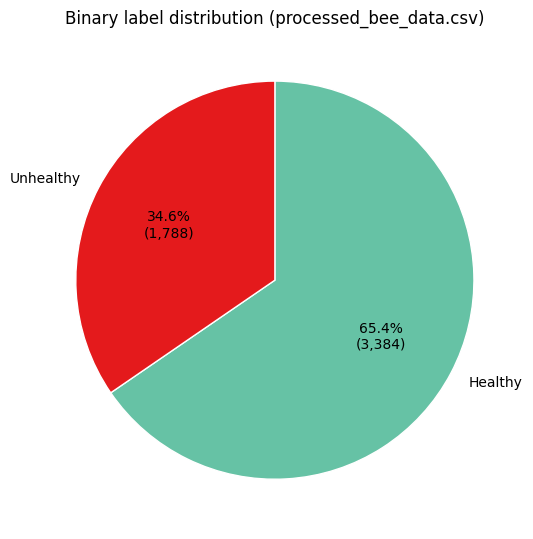

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load processed dataset and count how many images belong to each binary health label
processed_df = pd.read_csv("../data/processed/processed_bee_data_20260330_151740.csv", sep=";")

binary_counts = (
    processed_df["health"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
    .reindex(["healthy", "unhealthy"])
    .fillna(0)
    .astype(int)
)

# Convert label names to title case and define fixed colors for the two classes
pie_labels = [label.title() for label in binary_counts.index]
pie_colors = ["#66c2a5", "#e41a1c"]

# Show percentage and absolute count inside each slice
def autopct_with_count(values):
    total = sum(values)
    def _formatter(pct):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count:,})"
    return _formatter

# Pie chart that shows processed binary label distribution
plt.figure(figsize=(7, 5.5))
plt.pie(
    binary_counts.values,
    labels=pie_labels,
    colors=pie_colors,
    autopct=autopct_with_count(binary_counts.values),
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 10},
)
plt.title("Binary label distribution (processed_bee_data.csv)")
plt.tight_layout()
plt.show()

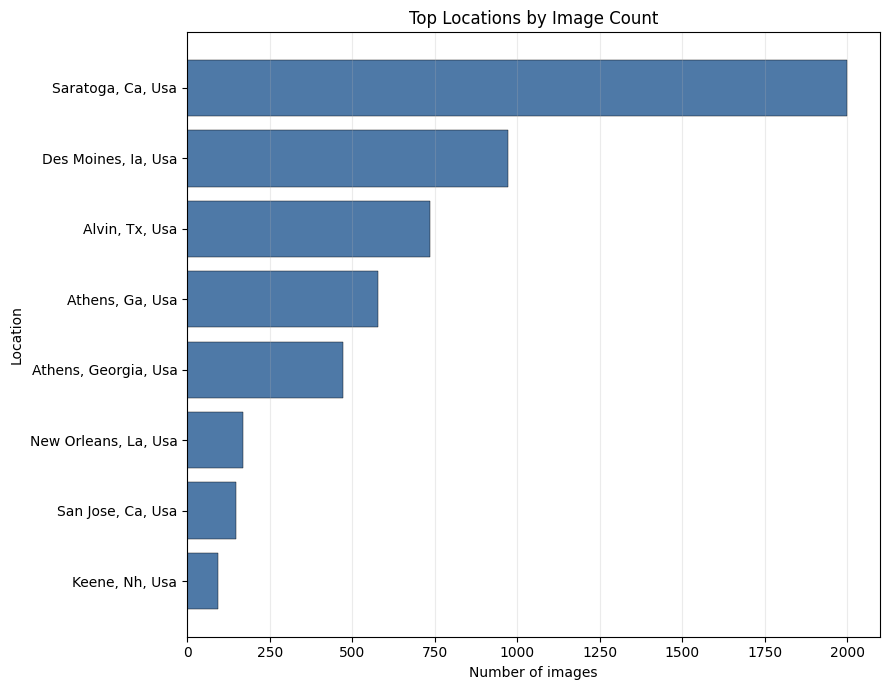

In [1]:
# Top locations by image count

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/bee_data.csv")


location_counts = df["location"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(
    location_counts.index.str.title(),
    location_counts.values,
    color="#4e79a7",
    edgecolor="black",
    linewidth=0.3,
 )
plt.title("Top Locations by Image Count")
plt.xlabel("Number of images")
plt.ylabel("Location")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

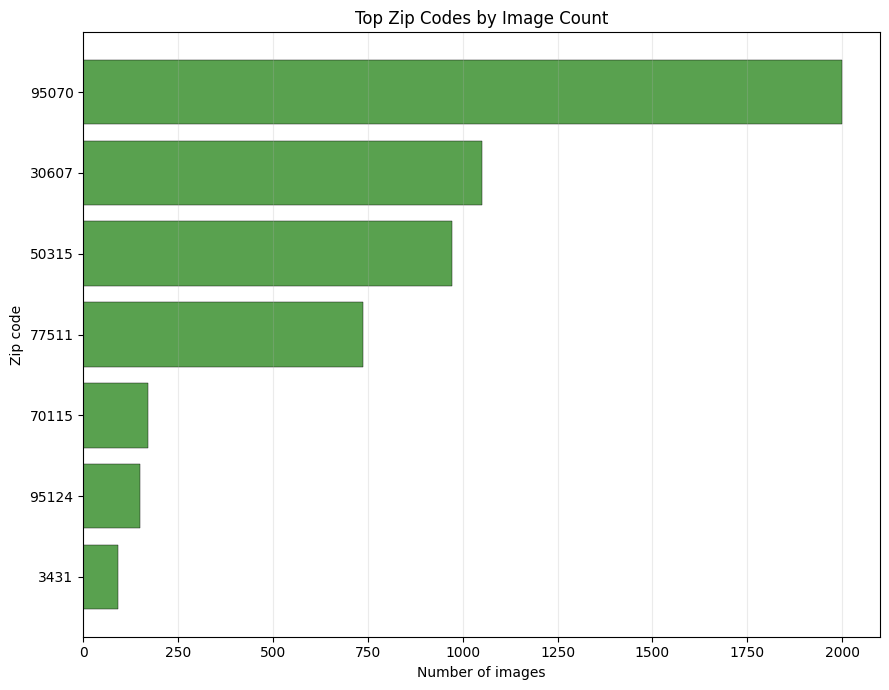

In [ ]:
# Top zip codes by image count

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/bee_data.csv")


zip_counts = df["zip code"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(
    zip_counts.index.astype(str),
    zip_counts.values,
    color="#59a14f",
    edgecolor="black",
    linewidth=0.3,
 )
plt.title("Top Zip Codes by Image Count")
plt.xlabel("Number of images")
plt.ylabel("Zip code")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

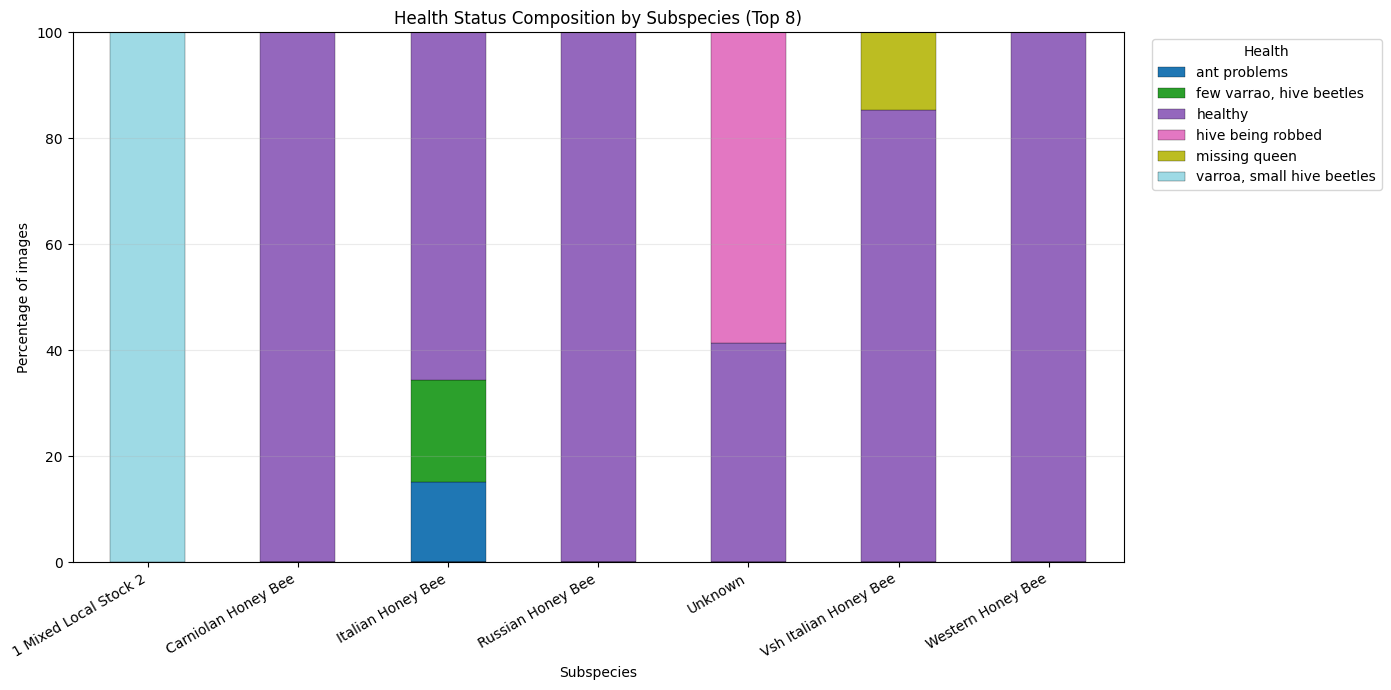

In [ ]:
# Visualize health label within most frequent subspecies

import pandas as pd
import matplotlib.pyplot as plt

# Keep only top N subspecies so the chart stays readable
top_subspecies_n = 8
top_subspecies = df["subspecies"].value_counts().head(top_subspecies_n).index
sub_df = df[df["subspecies"].isin(top_subspecies)].copy()

# Compute percentage split of health labels within each selected subspecies
subspecies_health = pd.crosstab(sub_df["subspecies"], sub_df["health"], normalize="index") * 100
subspecies_health = subspecies_health.sort_index()

# Stacked bar chart showing health status percentages
ax = subspecies_health.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    colormap="tab20",
    edgecolor="black",
    linewidth=0.2,
)
ax.set_title(f"Health Status Composition by Subspecies (Top {top_subspecies_n})")
ax.set_xlabel("Subspecies")
ax.set_ylabel("Percentage of images")
ax.set_ylim(0, 100)
ax.set_xticklabels([s.title() for s in subspecies_health.index], rotation=30, ha="right")
ax.legend(title="Health", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

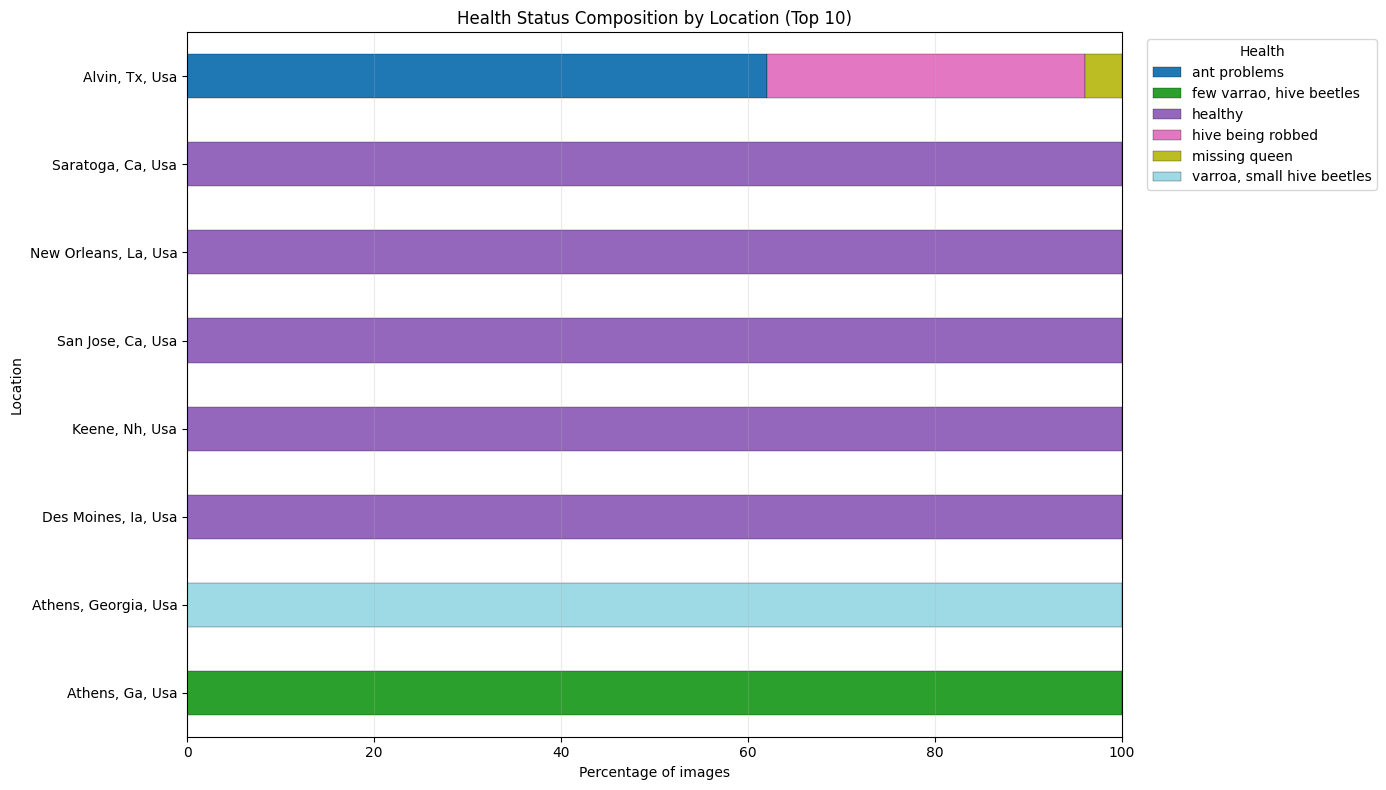

In [ ]:
# Visualize health labels within the most frequent locations

import pandas as pd
import matplotlib.pyplot as plt

# Keep only the top N locations so the chart remains still readable
top_locations_n = 10
top_locations = df["location"].value_counts().head(top_locations_n).index
loc_df = df[df["location"].isin(top_locations)].copy()

# Compute percentage split of health labels within each selected location
location_health = pd.crosstab(loc_df["location"], loc_df["health"], normalize="index") * 100
location_health = location_health.loc[location_health.sum(axis=1).sort_values(ascending=False).index]

# Stacked horizontal bar chart showing how health stats percentages vary
ax = location_health.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 8),
    colormap="tab20",
    edgecolor="black",
    linewidth=0.2,
)
ax.set_title(f"Health Status Composition by Location (Top {top_locations_n})")
ax.set_xlabel("Percentage of images")
ax.set_ylabel("Location")
ax.set_xlim(0, 100)
ax.set_yticklabels([s.title() for s in location_health.index])
ax.legend(title="Health", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()